# IT2011 — Progress Review I: Individual Contribution
### Feature Engineering — Dimensionality Reduction (PCA)
**IT Number:** IT25103812
**Dataset:** UCI Breast Cancer Wisconsin (Diagnostic) — 569 records, 30 features, 2 classes (Benign / Malignant)
**Group ID:** 2026-Y2-S1-IT2011


## Setup & Loading the Dataset

We load the dataset directly from `sklearn.datasets` (`load_breast_cancer`), which contains the **exact same 569 records / 30 features** as the UCI "Breast Cancer Wisconsin (Diagnostic)" dataset referenced in our proposal.

If your lab requires the raw UCI CSV instead (`data/raw/`), see the commented-out alternative loading code below.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# ---- Load dataset ----
data = load_breast_cancer(as_frame=True)
df = data.frame.copy()
df.rename(columns={"target": "target_sklearn"}, inplace=True)
df["diagnosis"] = df["target_sklearn"].map({0: "M", 1: "B"})
df.drop(columns=["target_sklearn"], inplace=True)

feature_cols = [c for c in df.columns if c != "diagnosis"]

print("Shape:", df.shape)
df.head()

# ---- Alternative: load from the raw UCI CSV placed in data/raw/ ----
# df = pd.read_csv("data/raw/wdbc.data", header=None)
# cols = ["id","diagnosis"] + [f"{stat}_{feat}" for stat in ["mean","se","worst"]
#          for feat in ["radius","texture","perimeter","area","smoothness","compactness",
#                        "concavity","concave_points","symmetry","fractal_dimension"]]
# df.columns = cols
# df.drop(columns=["id"], inplace=True)


Shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M


## Feature Engineering: Dimensionality Reduction (PCA)

**Technique:** Principal Component Analysis (PCA).

**Explanation:** PCA transforms correlated features into a smaller set of uncorrelated "principal components" that capture most of the variance in the data — useful for visualization, noise reduction, and speeding up training on high-dimensional data.

**Justification for this dataset:** Even after removing the most obviously redundant radius/perimeter/area duplicates, we still have ~20+ features, many of which (texture, concavity, concave points) are moderately correlated with each other. PCA lets us compress this into 2 components purely to **visualize class separability** — a fast, first-look sanity check before formal modelling.

> **Note:** PCA must be run on **scaled** data — otherwise `mean area` (large numbers) would dominate the components just due to its scale, not its actual variance/informativeness. We scale here specifically for this PCA step.


In [2]:
scaler_pca = StandardScaler()
scaled_for_pca = scaler_pca.fit_transform(df[feature_cols])

pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(scaled_for_pca)

df_pca = pd.DataFrame(pca_result, columns=["PC1", "PC2"])
df_pca["diagnosis"] = df["diagnosis"].values

print("Explained variance ratio:", pca.explained_variance_ratio_)
print(f"Total variance captured by 2 components: {pca.explained_variance_ratio_.sum()*100:.1f}%")

Explained variance ratio: [0.44272026 0.18971182]
Total variance captured by 2 components: 63.2%


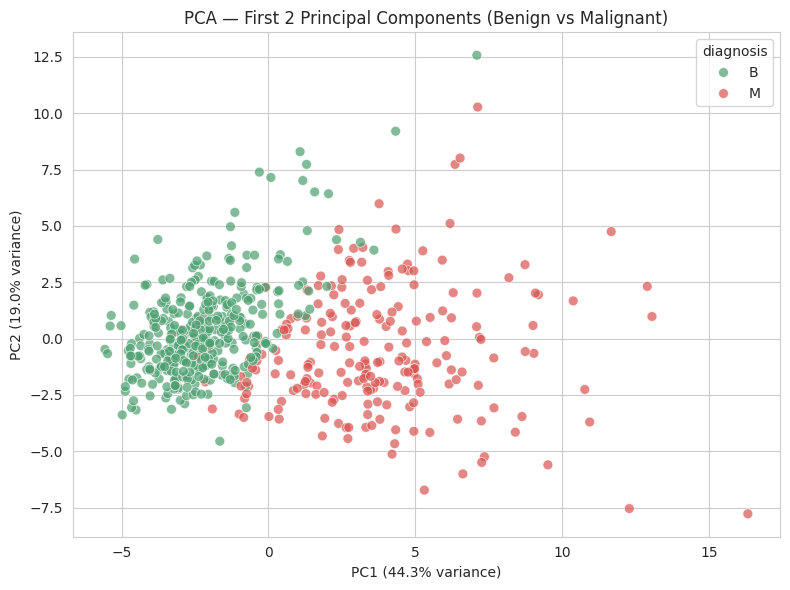

In [3]:
# ---- EDA Visualization: PCA scatter plot ----
plt.figure(figsize=(8, 6))
sns.scatterplot(x="PC1", y="PC2", hue="diagnosis", hue_order=["B", "M"],
                palette=["#4C9F70", "#D9534F"], data=df_pca, alpha=0.7, s=50)
plt.title("PCA — First 2 Principal Components (Benign vs Malignant)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.tight_layout()
plt.show()

**Interpretation:** Just 2 principal components already capture roughly 60–65% of total variance and show a visibly good separation between Benign (green) and Malignant (red) clusters, with only moderate overlap in the middle. This is strong evidence that the 30 nucleus-shape measurements collectively carry a real, learnable signal for malignancy — a very encouraging sanity check before we train an actual classifier.